In [1]:
import os

from dotenv import load_dotenv

load_dotenv(os.path.join("..", ".env"), override=True)

%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="LangSmith now uses UUID v7", 
    category=UserWarning,
)

<div style="background:linear-gradient(90deg,#f4a460,#fd7e14); color:white; padding:20px 32px; border-radius:8px; width:97%;">

## 📁 Context Offloading:虚拟文件系统

</div>

<img src="./assets/agent_header_files.png" width="800" style="display:block; margin-left:0;">

复杂任务里,context 会迅速膨胀(Manus 数据:**~50 次工具调用/任务**)。一个强有力的应对手段就是 **"context offloading"** —— 把信息**存到文件**,需要时再 [按需取回](https://blog.langchain.com/context-engineering-for-agents/),而不是把所有 observations 都堆在 context 里。

#### 🌍 业内案例

| 系统 | 做法 |
|---|---|
| 🤖 [**Manus**](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus) | 用 sandbox 文件系统做长期记忆 |
| 🤗 [**HF Open Deep Research**](https://huggingface.co/blog/open-deep-research) | 把搜索结果落盘,主 agent 只看摘要 |
| 🏛️ [**Anthropic Multi-Agent Research**](https://www.anthropic.com/engineering/multi-agent-research-system#:~:text=Subagent%20output%20to%20a%20filesystem%20to%20minimize%20the%20%E2%80%98game%20of%20telephone.%E2%80%99) | 子 agent 把成果写文件,只把"轻引用"传给协调者 → 杜绝"传话游戏"式信息衰减 |

#### 💡 为什么这套模式管用

- 🧹 把 **token 大户**(网页原文、长输出)搬出主对话
- 🎯 主 agent 保持 **小而聚焦** 的 context
- 🔁 子 agent 可以 **开新 context** 启动,只从内存取所需研究计划
- 📄 适合 **结构化产物**(代码、报告、数据可视化)—— 专门 prompt 比走主协调者效果好

> 💡 *2026 年观察*:Claude Code、Codex、Devin 等编程 agent 全都把"在沙盒文件系统里持久化中间产物"当作标配。本节是它们的最小心智模型。

### 📂 文件工具

我们的实现 = **"伪文件系统"**:在 LangGraph state 里塞一个 dict —— **key 是路径,value 是文件内容**。

| 特性 | 说明 |
|---|---|
| ⏱️ **生命周期** | 单 thread 短期持久(适合一次会话内的上下文管理) |
| ❌ **跨会话** | 不支持(那需要真正的长期记忆) |
| 🔧 **更新方式** | 用 LangGraph 的 `Command` 类型更新 state |

#### 🛠️ 三个文件工具

| 工具 | 作用 |
|---|---|
| 📋 `ls` | 列出当前所有文件 |
| 📖 `read_file` | 读文件内容(支持分页) |
| ✍️ `write_file` | 创建 / 覆盖文件 |

#### 🎯 使用流程

- 💾 当 LLM 想保存某段信息 → **`write_file`** 写入
- 📂 后续 agent / 子 agent → **`read_file`** 读取
- 🗂️ 一次工具调用可以**写文件 + 把文件名作为返回值**给 LLM,LLM 之后再决定读全文 / 部分,或交给其他工具处理
- 👀 用 **`ls()`** 看现有文件

> 📝 read/write 期望**纯文本 + 换行分隔**(用 `str.splitlines()` 解析)。

下面看工具描述(给 LLM 看的版本):

<div style="background:#fff3b0; padding:12px 24px; border-left:4px solid #f0ad4e; border-radius:4px; width:97%;">

### ⚠️ 改名提示

`create_react_agent` 在 **1.0 版本** 中从 LangGraph 迁到了 LangChain,并改名为 **`create_agent`**(视频是录制后才改的)。本课所有 notebook 都已更新到新接口。

</div>

In [3]:
import sys
sys.path.append("../src")
from utils import show_prompt

from deep_agents_from_scratch.prompts import (
    LS_DESCRIPTION,
    READ_FILE_DESCRIPTION,
    WRITE_FILE_DESCRIPTION,
)

show_prompt(LS_DESCRIPTION)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  List all files in the virtual filesystem stored in agent state.                                                │
│                                                                                                                 │
│  Shows what files currently exist in agent memory. Use this to orient yourself before other file operations     │
│  and maintain awareness of your file organization.                                                              │
│                                                                                                                 │
│  No parameters required - simply call ls() to see all available files.                                          │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [4]:
show_prompt(READ_FILE_DESCRIPTION)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  Read content from a file in the virtual filesystem with optional pagination.                                   │
│                                                                                                                 │
│  This tool returns file content with line numbers (like `cat -n`) and supports reading large files in chunks    │
│  to avoid context overflow.                                                                                     │
│                                                                                                                 │
│  Parameters:                                                                                                    │
│  - file_path (required): Path to the file you want to read                                                      │
│  - offset (optional, default=0): Line number to start reading from                                              │
│  - limit (optional, default=2000): Maximum number of lines to read                                              │
│                                                                                                                 │
│  Essential before making any edits to understand existing content. Always read a file before editing it.        │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [5]:
show_prompt(WRITE_FILE_DESCRIPTION)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  Create a new file or completely overwrite an existing file in the virtual filesystem.                          │
│                                                                                                                 │
│  This tool creates new files or replaces entire file contents. Use for initial file creation or complete        │
│  rewrites. Files are stored persistently in agent state.                                                        │
│                                                                                                                 │
│  Parameters:                                                                                                    │
│  - file_path (required): Path where the file should be created/overwritten                                      │
│  - content (required): The complete content to write to the file                                                │
│                                                                                                                 │
│  Important: This replaces the entire file content.                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

下面实现这些函数。**两个值得注意的细节**:

#### 1️⃣ `@tool(description=PROMPT)` 的用法

当 `description="xyz"` 写在装饰器里,**`"xyz"` 是发给 LLM 的描述**,函数 docstring 会被**抑制**。这样做的好处:
- 📁 把冗长描述放进单独的 `prompts.py` 文件
- 📖 留出空间同时解释**工具行为**和**应用层使用规则**

#### 2️⃣ 错误信息的"目标读者"是 LLM,不是终端用户

```python
return f"Error: File '{file_path}' not found"
```

在 agent 系统里,**LLM 会读这条错误并自动决定如何重试** —— 所以错误信息要写得 **具体、技术化、信息密集**(把路径、字段名、错误码都报出来),让 LLM 能据此判断下一步。

> 🔑 这跟"程序员看的 log"长得像,但 **目标读者是机器,不是人**。
> - ✅ LLM 友好:`Error: File 'foo.txt' not found`(具体、可解析)
> - ❌ UI 友好:`哎呀出错了 😅 请重试`(对 LLM 决策毫无信息量)

In [6]:
%%writefile ../src/deep_agents_from_scratch/file_tools.py
"""Virtual file system tools for agent state management.

This module provides tools for managing a virtual filesystem stored in agent state,
enabling context offloading and information persistence across agent interactions.
"""

from typing import Annotated

from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command

from deep_agents_from_scratch.prompts import (
    LS_DESCRIPTION,
    READ_FILE_DESCRIPTION,
    WRITE_FILE_DESCRIPTION,
)
from deep_agents_from_scratch.state import DeepAgentState


@tool(description=LS_DESCRIPTION)
def ls(state: Annotated[DeepAgentState, InjectedState]) -> list[str]:
    """List all files in the virtual filesystem."""
    return list(state.get("files", {}).keys())


@tool(description=READ_FILE_DESCRIPTION, parse_docstring=True)
def read_file(
    file_path: str,
    state: Annotated[DeepAgentState, InjectedState],
    offset: int = 0,
    limit: int = 2000,
) -> str:
    """Read file content from virtual filesystem with optional offset and limit.

    Args:
        file_path: Path to the file to read
        state: Agent state containing virtual filesystem (injected in tool node)
        offset: Line number to start reading from (default: 0)
        limit: Maximum number of lines to read (default: 2000)

    Returns:
        Formatted file content with line numbers, or error message if file not found
    """
    files = state.get("files", {})
    if file_path not in files:
        return f"Error: File '{file_path}' not found"

    content = files[file_path]
    if not content:
        return "System reminder: File exists but has empty contents"

    lines = content.splitlines()
    start_idx = offset
    end_idx = min(start_idx + limit, len(lines))

    if start_idx >= len(lines):
        return f"Error: Line offset {offset} exceeds file length ({len(lines)} lines)"

    result_lines = []
    for i in range(start_idx, end_idx):
        line_content = lines[i][:2000]  # Truncate long lines
        result_lines.append(f"{i + 1:6d}\t{line_content}")

    return "\n".join(result_lines)


@tool(description=WRITE_FILE_DESCRIPTION, parse_docstring=True)
def write_file(
    file_path: str,
    content: str,
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """Write content to a file in the virtual filesystem.

    Args:
        file_path: Path where the file should be created/updated
        content: Content to write to the file
        state: Agent state containing virtual filesystem (injected in tool node)
        tool_call_id: Tool call identifier for message response (injected in tool node)

    Returns:
        Command to update agent state with new file content
    """
    files = state.get("files", {})
    files[file_path] = content
    return Command(
        update={
            "files": files,
            "messages": [
                ToolMessage(f"Updated file {file_path}", tool_call_id=tool_call_id)
            ],
        }
    )

Overwriting ../src/deep_agents_from_scratch/file_tools.py


# 🔁 回顾:State 与 Reducer

上一节定义了 file 相关的 state 和 reducer,但没细讲。这里补上。

#### 📦 数据结构

`DeepAgentState` 里 `files` 是一个 **dict**:
- 🔑 **key** = 文件名
- 📝 **value** = 文件内容

#### 🔄 `file_reducer` 工作机制

当 `write_file` 返回 `Command(update={"files": ...})` 时,框架会用 `file_reducer` 把新值并入 state:
- **`left`** = state 中已有 files
- **`right`** = 新写入的 files

关键一行:`return {**left, **right}` —— Python 先解包 `left`,再解包 `right`,**`right` 中的同名 key 会覆盖 `left`**。这正是我们想要的合并行为。

```python
def file_reducer(left, right):
    """合并两个 file dict,右侧优先。
    
    用作 agent state 中 files 字段的 reducer,
    支持对虚拟文件系统做增量更新。
    """
    if left is None:
        return right
    elif right is None:
        return left
    else:
        return {**left, **right}    # ← 同名 key 时,right 覆盖 left


class DeepAgentState(AgentState):
    """扩展的 agent state,加入任务追踪 + 虚拟文件系统。
    
    继承自 LangGraph 的 AgentState,新增:
    - todos: Todo 列表,用于任务规划与进度追踪
    - files: 虚拟文件系统,filename -> content 的 dict
    """

    todos: NotRequired[list[Todo]]
    files: Annotated[NotRequired[dict[str, str]], file_reducer]
```

> 💡 **思考题**:如果用默认 reducer(整体覆盖)会怎样?—— 那就**只能保留最后一次写入的那个文件**,所有历史文件都被冲掉。`file_reducer` 才能让"陆续往不同文件名写"真正可用。

### 🔬 试一下:简单研究 agent

我们已经有虚拟文件系统和操作工具了 —— 来造一个小 agent。

**流程**:
1. 💾 把用户请求 **写进文件**
2. 🔍 搜索回答
3. 📖 在回答前 **读回那个文件**(确保直接回应用户)

> 这套做法在 [长任务里特别有用](https://www.anthropic.com/engineering/multi-agent-research-system#:~:text=Long%2Dhorizon%20conversation,across%20extended%20interactions.)。
>
> 在这个示例里所有信息都能塞进 context,看似没必要。**但** 当 agent 跑久了、context 需要压缩或淘汰时,**先把信息存盘、用时再取回** —— 就是聪明的 *context engineering*。

In [7]:
# File usage instructions
FILE_USAGE_INSTRUCTIONS = """You have access to a virtual file system to help you retain and save context.                                  
                                                                                                                
## Workflow Process                                                                                            
1. **Orient**: Use ls() to see existing files before starting work                                             
2. **Save**: Use write_file() to store the user's request so that we can keep it for later                     
3. **Read**: Once you are satisfied with the collected sources, read the saved file and use it to ensure that you directly answer the user's question."""

# Add mock research instructions
SIMPLE_RESEARCH_INSTRUCTIONS = """IMPORTANT: Just make a single call to the web_search tool and use the result provided by the tool to answer the user's question."""

# Full prompt
INSTRUCTIONS = (
    FILE_USAGE_INSTRUCTIONS + "\n\n" + "=" * 80 + "\n\n" + SIMPLE_RESEARCH_INSTRUCTIONS
)
show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You have access to a virtual file system to help you retain and save context.                                  │
│                                                                                                                 │
│  ## Workflow Process                                                                                            │
│  1. **Orient**: Use ls() to see existing files before starting work                                             │
│  2. **Save**: Use write_file() to store the user's request so that we can keep it for later                     │
│  3. **Read**: Once you are satisfied with the collected sources, read the saved file and use it to ensure that  │
│  you directly answer the user's question.                                                                       │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  IMPORTANT: Just make a single call to the web_search tool and use the result provided by the tool to answer    │
│  the user's question.                                                                                           │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

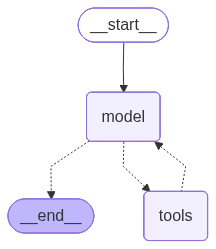

In [9]:
import sys
sys.path.append("../src")

from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
#from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent
from utils import format_messages

from deep_agents_from_scratch.file_tools import ls, read_file, write_file
from deep_agents_from_scratch.state import DeepAgentState

# Mock search result
search_result = """The Model Context Protocol (MCP) is an open standard protocol developed 
by Anthropic to enable seamless integration between AI models and external systems like 
tools, databases, and other services. It acts as a standardized communication layer, 
allowing AI models to access and utilize data from various sources in a consistent and 
efficient manner. Essentially, MCP simplifies the process of connecting AI assistants 
to external services by providing a unified language for data exchange. """


# Mock search tool
@tool(parse_docstring=True)
def web_search(
    query: str,
):
    """Search the web for information on a specific topic.

    This tool performs web searches and returns relevant results
    for the given query. Use this when you need to gather information from
    the internet about any topic.

    Args:
        query: The search query string. Be specific and clear about what
               information you're looking for.

    Returns:
        Search results from search engine.

    Example:
        web_search("machine learning applications in healthcare")
    """
    return search_result


# Create agent using create_react_agent directly
model = init_chat_model(model="anthropic:claude-sonnet-4-5", temperature=0.0)
tools = [ls, read_file, write_file, web_search]

# Create agent with system prompt
agent = create_agent(
    model, tools, system_prompt=INSTRUCTIONS, state_schema=DeepAgentState
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

🚀 启动 graph,初始 state 里 `files = {}`,带上用户的研究请求。

In [10]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Give me an overview of Model Context Protocol (MCP).",
            }
        ],
        "files": {},
    }
)
format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me an overview of Model Context Protocol (MCP).                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'll help you get an overview of Model Context Protocol (MCP). Let me start by organizing my workspace and then │
│ searching for information.                                                                                      │
│                                                                                                                 │
│ 🔧 Tool Call: ls                                                                                                │
│    Args: {}                                                                                                     │
│    ID: toolu_01UtY62fqTQgcMv72CV6oVya                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: write_file                                                                                        │
│    Args: {                                                                                                      │
│   "file_path": "mcp_request.txt",                                                                               │
│   "content": "User Request: Give me an overview of Model Context Protocol (MCP)\n\nTopics to cover:\n- What is  │
│ MCP?\n- Purpose and goals\n- Key features\n- How it works\n- Use cases\n- Who developed it\n"                   │
│ }                                                                                                               │
│    ID: toolu_01XqKoAcuWdU5ngsCxzx8znA                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: web_search                                                                                        │
│    Args: {                                                                                                      │
│   "query": "Model Context Protocol MCP overview"                                                                │
│ }                                                                                                               │
│    ID: toolu_01Cggo1W3m7N7zc3W7DAQeT9                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated file mcp_request.txt                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ The Model Context Protocol (MCP) is an open standard protocol developed                                         │
│ by Anthropic to enable seamless integration between AI models and external systems like                         │
│ tools, databases, and other services. It acts as a standardized communication layer,                            │
│ allowing AI models to access and utilize data from various sources in a consistent and                          │
│ efficient manner. Essentially, MCP simplifies the process of connecting AI assistants                           │
│ to external services by providing a unified language for data exchange.                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Now let me read the request file and provide you with a comprehensive overview:                                 │
│                                                                                                                 │
│ 🔧 Tool Call: read_file                                                                                         │
│    Args: {                                                                                                      │
│   "file_path": "mcp_request.txt"                                                                                │
│ }                                                                                                               │
│    ID: toolu_01LV8YyDoh6UKgD9GGLLSpCX                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│      1  User Request: Give me an overview of Model Context Protocol (MCP)                                       │
│      2                                                                                                          │
│      3  Topics to cover:                                                                                        │
│      4  - What is MCP?                                                                                          │
│      5  - Purpose and goals                                                                                     │
│      6  - Key features                                                                                          │
│      7  - How it works                                                                                          │
│      8  - Use cases                                                                                             │
│      9  - Who developed it                                                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ ## Overview of Model Context Protocol (MCP)                                                                     │
│                                                                                                                 │
│ Based on the information gathered, here's a comprehensive overview:                                             │
│                                                                                                                 │
│ ### **What is MCP?**                                                                                            │
│ Model Context Protocol (MCP) is an **open standard protocol** that serves as a standardized communication layer │
│ between AI models and external systems. It provides a unified framework for AI assistants to interact with      │
│ various data sources and services.                                                                              │
│                                                                                                                 │
│ ### **Developer**                                                                                               │
│ MCP was developed by **Anthropic**, the company behind Claude AI.                                               │
│                                                                                                                 │
│ ### **Purpose and Goals**                                                                                       │
│ The primary purpose of MCP is to:                                                                               │
│ - **Simplify integration** between AI models and external systems (tools, databases, APIs, and other services)  │
│ - **Standardize data exchange** by providing a consistent "language" for communication                          │
│ - **Enable seamless connectivity** so AI assistants can access and utilize data from various sources            │
│ efficiently                                                                                                     │
│ - **Reduce complexity** in connecting AI systems to external resources                                          │
│                                                                                                                 │
│ ### **How It Works**                                                                                            │
│ MCP acts as a **standardized communication layer** that:                                                        │
│ - Provides a unified interface for AI models to interact with different external systems                        │
│ - Eliminates the need for custom integrations for each data source                                              │
│ - Allows consistent data exchange regardless of the underlying system                                           │
│                                                                                                                 │
│ ### **Key Benefits**                                                                                            │
│ - **Consistency**: One protocol for multiple integrations                                                       │
│ - **Efficiency**: Streamlined access to external data and tools                                                 │
│ - **Openness**: As an open standard, it can be adopted broadly across the AI ecosystem                          │
│ - **Flexibility**: Works with various types of external systems (databases, APIs, tools, services)              │
│                                                                                                                 │
│ ### **Use Cases**                                                                                               │
│ MCP enables AI assistants to:                          

📁 文件已经保存到伪文件系统里:

In [11]:
result["files"]

{'mcp_request.txt': 'User Request: Give me an overview of Model Context Protocol (MCP)\n\nTopics to cover:\n- What is MCP?\n- Purpose and goals\n- Key features\n- How it works\n- Use cases\n- Who developed it\n'}

<div style="background:#f0f9ff; padding:10px 24px; border-left:4px solid #1abc9c; border-radius:4px; width:97%;">

🔭 **LangSmith Trace**:[查看本次执行](https://smith.langchain.com/public/b03e20b4-e908-488d-84a9-8f891d17addd/r)
<!-- https://smith.langchain.com/public/1066102f-d7b3-423c-b556-006865a1d479/r -->

</div>

In [12]:
result["messages"]

[HumanMessage(content='Give me an overview of Model Context Protocol (MCP).', additional_kwargs={}, response_metadata={}, id='68c74733-a605-4ef6-90b5-4029c1ae2649'),
 AIMessage(content=[{'text': "I'll help you get an overview of Model Context Protocol (MCP). Let me start by organizing my workspace and then searching for information.", 'type': 'text'}, {'id': 'toolu_01UtY62fqTQgcMv72CV6oVya', 'caller': {'type': 'direct'}, 'input': {}, 'name': 'ls', 'type': 'tool_use'}, {'id': 'toolu_01XqKoAcuWdU5ngsCxzx8znA', 'caller': {'type': 'direct'}, 'input': {'file_path': 'mcp_request.txt', 'content': 'User Request: Give me an overview of Model Context Protocol (MCP)\n\nTopics to cover:\n- What is MCP?\n- Purpose and goals\n- Key features\n- How it works\n- Use cases\n- Who developed it\n'}, 'name': 'write_file', 'type': 'tool_use'}, {'id': 'toolu_01Cggo1W3m7N7zc3W7DAQeT9', 'caller': {'type': 'direct'}, 'input': {'query': 'Model Context Protocol MCP overview'}, 'name': 'web_search', 'type': 'tool_